# Task #2c — Data Profiling: `florida_cyanotoxins`

**Issue:** [Break-Through-Tech/Biointerphase-1C-forecasting-harmful-algal-bloom-risk#5](https://github.com/Break-Through-Tech/Biointerphase-1C-forecasting-harmful-algal-bloom-risk/issues/5)

**Goal:** Profile `florida_cyanotoxins` to get a high-level overview — row counts, numeric vs. categorical columns, missing values, duplicates, invalid values, and outliers — and propose a handling strategy for each issue found.

**Deliverable:** Short data-quality summary + proposed handling strategy (see the summary section at the end of this notebook).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_DIR = "../data"
CYANO_PATH = f"{DATA_DIR}/florida_cyanotoxins_2015-01-01_to_2026-06-17.csv"

In [2]:
def profile_dataset(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Return a per-column profile: dtype, inferred kind, missingness, uniqueness."""
    n_rows = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        n_missing = s.isna().sum()
        n_unique = s.nunique(dropna=True)
        if pd.api.types.is_numeric_dtype(s):
            kind = "numeric"
        elif pd.api.types.is_bool_dtype(s):
            kind = "boolean"
        else:
            kind = "categorical/text"
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "kind": kind,
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / n_rows, 2) if n_rows else 0,
            "n_unique": n_unique,
            "sample_values": list(s.dropna().unique()[:3]),
        })
    profile = pd.DataFrame(rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
    print(f"[{name}] shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"[{name}] fully-empty columns: {(profile['pct_missing'] == 100).sum()}")
    print(f"[{name}] exact duplicate rows: {df.duplicated().sum():,}")
    return profile

## 1. Load and high-level overview

In [3]:
cyano = pd.read_csv(CYANO_PATH, low_memory=False)
cyano.head()

,Org_Identifier,Org_FormalName,Project_Identifier,Location_Identifier,Location_Name,Location_Type,Location_State,Location_HUCEightDigitCode,Location_HUCTwelveDigitCode,Location_TribalLand,Location_Latitude,Location_Longitude,Activity_ActivityIdentifier,Activity_TypeCode,Activity_Media,Activity_MediaSubdivision,ActivityBiological_AssemblageSa,Activity_StartDate,Activity_StartTime,Activity_StartTimeZone,Activity_DepthHeightMeasure,Activity_DepthHeightMeasureUnit,SampleCollectionMethod_Name,Result_ResultDetectionCondition,Result_Characteristic,Result_CharacteristicUserSuppli,Result_MethodSpeciation,Result_SampleFraction,ResultBiological_Intent,ResultBiological_Taxon,ResultDepthHeight_Measure,ResultDepthHeight_MeasureUnit,Result_MeasureIdentifier,Reslt_Measre,Result_MeasureUnit,Result_MeasureQualifierCode,Result_MeasureStatusIdentifier,Result_StatisticalBase,Result_MeasureValueType,DataQuality_ResultComment,DetectionLimit_TypeA,DetectionLimit_MeasureA,DetectionLimit_MeasureUnitA,DetectionLimit_CommentA,DetectionLimit_TypeB,DetectionLimit_MeasureB,DetectionLimit_MeasureUnitB,DetectionLimit_CommentB,ResultAnalyticalMethod_Identifi,ResultAnalyticalMethod_Identi_1,ResultAnalyticalMethod_Name,LabInfo_AnalysisStartDate,LabInfo_AnalysisStartTime,LabInfo_AnalysisStartTimeZone,ResultAnalyticalMethod_Url,Result_DetectionLimitProfileDow,Result_LabSamplePrepProfileDown,ProviderName,Result_CharacteristicComparable,Result_CharacteristicGroup,Org_Type,LastChangeDate,USGSpcode,ObjectId,Value_control
0,NARS_WQX,EPA National Aquatic Resources Survey (NARS),"[""NARS_NCCA2015""]",NARS_WQX-NCA_FL-10246,NCA_FL-10246,Ocean,Florida,NaN,NaN,NaN,27.887829,-82.557660,NARS_WQX-NCA_FL-10246:06012015:SR:AT,Sample-Routine,Water,NaN,NaN,1.433130e+12,NaN,NaN,NaN,NaN,NCCA Grab Sample,NaN,Microcystin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET-937617381,NaN,ug/L,NaN,Final,NaN,Actual,NaN,Minimum Reporting Level,0.263,ug/L,NaN,NaN,NaN,NaN,NaN,520011,ABRAXIS LLC,"Microcystins and Nodularins by Immunoassay, Mi...",NaN,NaN,NaN,NaN,https://www.waterqualitydata.us/data/providers...,NaN,STORET,NaN,"Cyanotoxins, Phytotoxins",Federal/US Government,Fri Jan 31 08:59:46 GMT 2025,NaN,23431,A
1,NARS_WQX,EPA National Aquatic Resources Survey (NARS),"[""NARS_NCCA2015""]",NARS_WQX-NCA_FL-10245,NCA_FL-10245,Ocean,Florida,NaN,NaN,NaN,27.906991,-82.480553,NARS_WQX-NCA_FL-10245:06022015:SR:AT,Sample-Routine,Water,NaN,NaN,1.433220e+12,NaN,NaN,NaN,NaN,NCCA Grab Sample,NaN,Microcystin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET-937617442,NaN,ug/L,NaN,Final,NaN,Actual,NaN,Minimum Reporting Level,0.263,ug/L,NaN,NaN,NaN,NaN,NaN,520011,ABRAXIS LLC,"Microcystins and Nodularins by Immunoassay, Mi...",NaN,NaN,NaN,NaN,https://www.waterqualitydata.us/data/providers...,NaN,STORET,NaN,"Cyanotoxins, Phytotoxins",Federal/US Government,Fri Jan 31 08:59:46 GMT 2025,NaN,22625,A
2,NARS_WQX,EPA National Aquatic Resources Survey (NARS),"[""NARS_NCCA2015""]",NARS_WQX-NCA_FL-10297,NCA_FL-10297,Ocean,Florida,NaN,NaN,NaN,27.936200,-82.426381,NARS_WQX-NCA_FL-10297:06022015:SR:AT,Sample-Routine,Water,NaN,NaN,1.433220e+12,NaN,NaN,NaN,NaN,NCCA Grab Sample,NaN,Microcystin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET-937617450,NaN,ug/L,NaN,Final,NaN,Actual,NaN,Minimum Reporting Level,0.263,ug/L,NaN,NaN,NaN,NaN,NaN,520011,ABRAXIS LLC,"Microcystins and Nodularins by Immunoassay, Mi...",NaN,NaN,NaN,NaN,https://www.waterqualitydata.us/data/providers...,NaN,STORET,NaN,"Cyanotoxins, Phytotoxins",Federal/US Government,Fri Jan 31 08:59:46 GMT 2025,NaN,22713,A
3,NARS_WQX,EPA National Aquatic Resources Survey (NARS),"[""NARS_NCCA2015""]",NARS_WQX-NCA_FL-10299,NCA_FL-10299,Ocean,Florida,NaN,NaN,NaN,27.646342,-82.703638,NARS_WQX-NCA_FL-10299:06032015:SR:AT,Sample-Routine,Water,NaN,NaN,1.433300e+12,NaN,NaN,NaN,NaN,NCCA Grab Sample,NaN,Microcystin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET-937617465,NaN,ug/L,NaN,Final,NaN,Actual,NaN,Minimum Reporting Level,0.263,ug/L,NaN,NaN,NaN,NaN,NaN,520011,ABRAXIS LLC,"Microcystins and Nodularins by Immunoassay, Mi...",NaN,NaN,Na

In [4]:
cyano_profile = profile_dataset(cyano, "florida_cyanotoxins")
cyano_profile

[florida_cyanotoxins] shape: 98,884 rows x 65 columns
[florida_cyanotoxins] fully-empty columns: 20


[florida_cyanotoxins] exact duplicate rows: 0


,column,dtype,kind,n_missing,pct_missing,n_unique,sample_values
0,ActivityBiological_AssemblageSa,float64,numeric,98884,100.0,0,[]
1,Result_LabSamplePrepProfileDown,float64,numeric,98884,100.0,0,[]
2,Location_TribalLand,float64,numeric,98884,100.0,0,[]
3,Result_CharacteristicUserSuppli,float64,numeric,98884,100.0,0,[]
4,ResultBiological_Taxon,float64,numeric,98884,100.0,0,[]
...,...,...,...,...,...,...,...
60,ProviderName,str,categorical/text,0,0.0,1,[STORET]
61,Org_Type,str,categorical/text,0,0.0,3,"[Federal/US Government, State/US Government, *..."
62,LastChangeDate,str,categorical/text,0,0.0,77,"[Fri Jan 31 08:59:46 GMT 2025, Mon Feb 27 12:4..."
63,ObjectId,int64,numeric,0,0.0,98884,"[23431, 22625, 22713]"


## 2. Numeric vs. categorical column split

In [5]:
cyano_numeric_cols = cyano_profile.loc[cyano_profile["kind"] == "numeric", "column"].tolist()
cyano_categorical_cols = cyano_profile.loc[cyano_profile["kind"] != "numeric", "column"].tolist()
print(f"Numeric columns ({len(cyano_numeric_cols)}): {cyano_numeric_cols}")
print(f"\nCategorical/text columns ({len(cyano_categorical_cols)}): {cyano_categorical_cols}")

Numeric columns (29): ['ActivityBiological_AssemblageSa', 'Result_LabSamplePrepProfileDown', 'Location_TribalLand', 'Result_CharacteristicUserSuppli', 'ResultBiological_Taxon', 'ResultDepthHeight_MeasureUnit', 'ResultDepthHeight_Measure', 'ResultBiological_Intent', 'Result_ResultDetectionCondition', 'Result_MethodSpeciation', 'DetectionLimit_TypeB', 'DetectionLimit_MeasureUnitB', 'DetectionLimit_MeasureB', 'DetectionLimit_CommentB', 'DetectionLimit_CommentA', 'Result_StatisticalBase', 'Result_MeasureQualifierCode', 'USGSpcode', 'ResultAnalyticalMethod_Url', 'Result_CharacteristicComparable', 'Location_HUCTwelveDigitCode', 'Activity_DepthHeightMeasure', 'Location_HUCEightDigitCode', 'Reslt_Measre', 'DetectionLimit_MeasureA', 'Location_Latitude', 'Location_Longitude', 'Activity_StartDate', 'ObjectId']

Categorical/text columns (36): ['DataQuality_ResultComment', 'Activity_MediaSubdivision', 'Activity_DepthHeightMeasureUnit', 'Activity_StartTime', 'Activity_StartTimeZone', 'LabInfo_Analys

## 3. Missing values

20 columns are 100% empty (WQX schema fields Florida's providers never populate, e.g. `ActivityBiological_AssemblageSa`, `Result_MethodSpeciation`, `USGSpcode`). The core analysis columns (site, date, location, characteristic, measured value, unit) are almost fully populated.

In [6]:
fully_empty = cyano_profile.loc[cyano_profile["pct_missing"] == 100, "column"].tolist()
print(f"Fully-empty columns ({len(fully_empty)}):")
for c in fully_empty:
    print(f"  - {c}")

print("\nColumns with partial (0% < missing < 100%) missingness:")
cyano_profile[(cyano_profile["pct_missing"] > 0) & (cyano_profile["pct_missing"] < 100)][["column", "n_missing", "pct_missing"]]

Fully-empty columns (20):
  - ActivityBiological_AssemblageSa
  - Result_LabSamplePrepProfileDown
  - Location_TribalLand
  - Result_CharacteristicUserSuppli
  - ResultBiological_Taxon
  - ResultDepthHeight_MeasureUnit
  - ResultDepthHeight_Measure
  - ResultBiological_Intent
  - Result_ResultDetectionCondition
  - Result_MethodSpeciation
  - DetectionLimit_TypeB
  - DetectionLimit_MeasureUnitB
  - DetectionLimit_MeasureB
  - DetectionLimit_CommentB
  - DetectionLimit_CommentA
  - Result_StatisticalBase
  - Result_MeasureQualifierCode
  - USGSpcode
  - ResultAnalyticalMethod_Url
  - Result_CharacteristicComparable

Columns with partial (0% < missing < 100%) missingness:


,column,n_missing,pct_missing
20,DataQuality_ResultComment,1772,1.79
21,Location_HUCTwelveDigitCode,308,0.31
22,Activity_MediaSubdivision,236,0.24
23,Activity_DepthHeightMeasureUnit,228,0.23
24,Activity_DepthHeightMeasure,228,0.23
25,Activity_StartTime,220,0.22
26,Activity_StartTimeZone,220,0.22
27,LabInfo_AnalysisStartTime,220,0.22
28,LabInfo_AnalysisStartTimeZone,220,0.22
29,Result_SampleFraction,220,0.22


## 4. Duplicates

In [7]:
print("Exact duplicate rows:", cyano.duplicated().sum())
print("Duplicate ObjectId (should be a unique row key):", cyano["ObjectId"].duplicated().sum())
print("Duplicate Result_MeasureIdentifier:", cyano["Result_MeasureIdentifier"].duplicated().sum())

Exact duplicate rows: 0
Duplicate ObjectId (should be a unique row key): 0
Duplicate Result_MeasureIdentifier: 0


## 5. Invalid values

Checks: dates outside the file's advertised range (2015-01-01 to 2026-06-17), coordinates outside Florida's bounding box, non-positive measured concentrations, and unit consistency.

In [8]:
# Activity_StartDate is stored as epoch milliseconds (e.g. 1.43313E+12), not a date string.
cyano["Activity_StartDate_parsed"] = pd.to_datetime(cyano["Activity_StartDate"], unit="ms", errors="coerce")

date_min, date_max = pd.Timestamp("2015-01-01"), pd.Timestamp("2026-06-17")
bad_dates = cyano[(cyano["Activity_StartDate_parsed"] < date_min) | (cyano["Activity_StartDate_parsed"] > date_max)]
unparseable_dates = cyano["Activity_StartDate_parsed"].isna().sum()

print("Parsed date range:", cyano["Activity_StartDate_parsed"].min(), "to", cyano["Activity_StartDate_parsed"].max())
print("Rows with dates outside advertised file range:", len(bad_dates))
print("Rows where date failed to parse:", unparseable_dates)

Parsed date range: 2015-06-01 03:40:00 to 2025-01-02 03:53:20
Rows with dates outside advertised file range: 0
Rows where date failed to parse: 0


In [9]:
# Florida's rough bounding box (incl. coastal waters)
FL_LAT_RANGE = (24.0, 31.5)
FL_LON_RANGE = (-88.0, -79.5)

bad_coords = cyano[
    ~cyano["Location_Latitude"].between(*FL_LAT_RANGE) |
    ~cyano["Location_Longitude"].between(*FL_LON_RANGE)
]
print("Latitude range:", cyano["Location_Latitude"].min(), "to", cyano["Location_Latitude"].max())
print("Longitude range:", cyano["Location_Longitude"].min(), "to", cyano["Location_Longitude"].max())
print("Rows with coordinates outside Florida bounding box:", len(bad_coords))
print("Missing coordinates:", cyano["Location_Latitude"].isna().sum(), cyano["Location_Longitude"].isna().sum())

Latitude range: 24.70726415 to 30.95169832
Longitude range: -87.43661833 to -80.03600772
Rows with coordinates outside Florida bounding box: 0
Missing coordinates: 0 0


In [10]:
print("Result_MeasureUnit value counts:\n", cyano["Result_MeasureUnit"].value_counts(dropna=False))
print("\nReslt_Measre (measured concentration) <= 0:", (cyano["Reslt_Measre"] <= 0).sum())
print("Reslt_Measre missing:", cyano["Reslt_Measre"].isna().sum())
print("\nDistinct cyanotoxin analytes (Result_Characteristic):", cyano["Result_Characteristic"].nunique())
cyano["Result_Characteristic"].value_counts()

Result_MeasureUnit value counts:
 Result_MeasureUnit
ug/L    98824
NaN        60
Name: count, dtype: int64

Reslt_Measre (measured concentration) <= 0: 0
Reslt_Measre missing: 131

Distinct cyanotoxin analytes (Result_Characteristic): 19


Result_Characteristic
Cylindrospermopsin             7147
Microcystin RR                 7107
Microcystin LA                 7107
Microcystin LR                 7107
Microcystin YR                 7107
Microcystin LY                 7097
Microcystin LF                 7097
Anatoxin-A                     7092
Microcystin LW                 6368
Microcystin WR                 6368
Microcystin LR, Desmethyl      6368
Microcystin HtyR               5352
Microcystin HilR               5352
Nodularin                      5257
Saxitoxin                      3471
Neosaxitoxin                   3172
Microcystins and nodularins     135
Microcystin                     100
Microcystins                     80
Name: count, dtype: int64

## 6. Outliers in measured concentration

`Reslt_Measre` mixes 16+ different cyanotoxin analytes in one column (all in `ug/L`), with very different natural concentration scales — outliers are computed **per analyte** using the IQR rule.

In [11]:
def iqr_outlier_count(s: pd.Series, k: float = 1.5) -> int:
    s = s.dropna()
    if s.empty:
        return 0
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return int(((s < lower) | (s > upper)).sum())

outlier_summary = (
    cyano.groupby("Result_Characteristic")["Reslt_Measre"]
    .agg(count="count", min="min", median="median", max="max")
)
outlier_summary["n_iqr_outliers"] = cyano.groupby("Result_Characteristic")["Reslt_Measre"].apply(iqr_outlier_count)
outlier_summary["pct_outliers"] = round(100 * outlier_summary["n_iqr_outliers"] / outlier_summary["count"], 2)
outlier_summary.sort_values("pct_outliers", ascending=False)

,count,min,median,max,n_iqr_outliers,pct_outliers
Result_Characteristic,,,,,,
Microcystin,5,0.184,0.193,0.285,1,20.00
Microcystins and nodularins,135,0.200,0.200,20.000,27,20.00
Microcystin LR,7107,0.250,0.250,780.000,1398,19.67
Microcystins,56,0.132,1.236,4.575,4,7.14
Saxitoxin,3471,0.250,0.500,5.000,154,4.44
Microcystin LA,7107,0.100,0.100,120.000,305,4.29
"Microcystin LR, Desmethyl",6368,0.250,0.250,90.000,257,4.04
Microcystin RR,7107,0.100,0.100,220.000,177,2.49
Cylindrospermopsin,7135,0.060,0.100,4.000,145,2.03


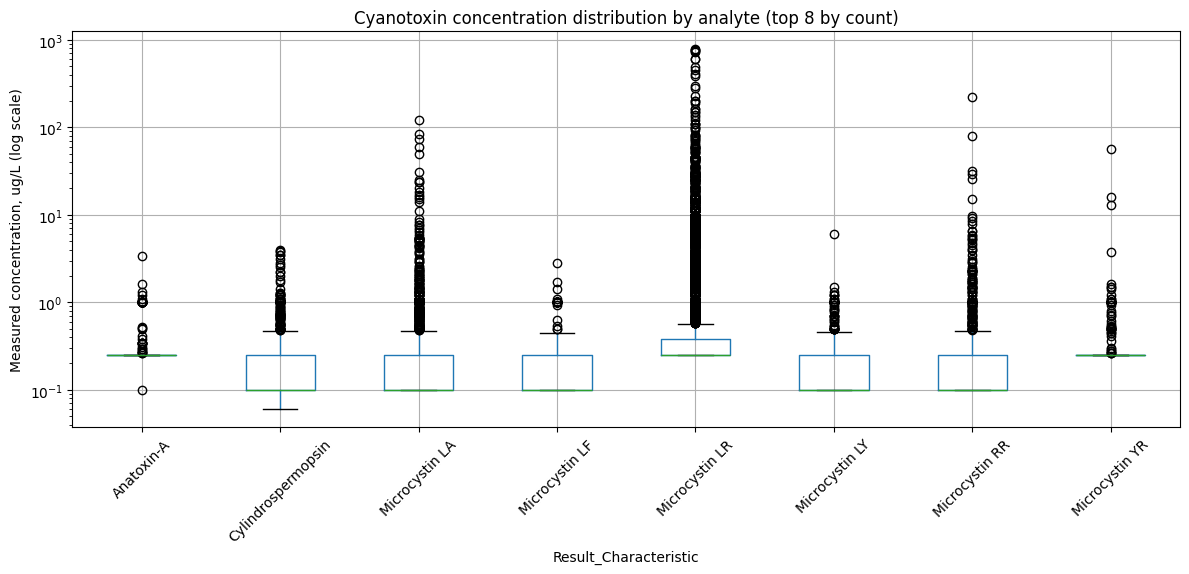

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
top_analytes = cyano["Result_Characteristic"].value_counts().head(8).index
cyano[cyano["Result_Characteristic"].isin(top_analytes)].boxplot(
    column="Reslt_Measre", by="Result_Characteristic", ax=ax, rot=45
)
ax.set_yscale("log")
ax.set_ylabel("Measured concentration, ug/L (log scale)")
ax.set_title("Cyanotoxin concentration distribution by analyte (top 8 by count)")
plt.suptitle("")
plt.tight_layout()
plt.show()